In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Collect an e-commerce sales dataset.
from google.colab import files

uploaded = files.upload()

Saving global_ecommerce_sales.csv to global_ecommerce_sales.csv


In [6]:
#Clean and preprocess the data using Pandas and NumPy
df = pd.read_csv("global_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [7]:
df.shape

(2000, 15)

In [8]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [10]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Customer_Segment,0
Country,0
Region,0
Product_Category,0
Product_Name,0
Quantity,0
Unit_Price,0


In [11]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Customer_Segment,0
Country,0
Region,0
Product_Category,0
Product_Name,0
Quantity,0
Unit_Price,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [14]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [15]:
# Check for invalid Quantity values
df[df["Quantity"] <= 0]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method


In [17]:
# Check for invalid Unit_Price values
df[df["Unit_Price"] <= 0]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method


In [18]:
# Check for invalid Total_Sales values
df[df["Total_Sales"] <= 0]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method


In [19]:
# Check for invalid Shipping_Cost values
df[df["Shipping_Cost"] < 0]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method


In [20]:
# Check for invalid Discount_Percent values
df[(df["Discount_Percent"] < 0) | (df["Discount_Percent"] > 100)]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method


In [21]:
#Analyze product sales, customer behavior, and revenue trends.
category_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)

category_sales

,Total_Sales
Product_Category,
Furniture,256274.68
Technology,139518.22
Clothing & Accessories,69375.63
Office Supplies,19390.81


In [22]:
# Analyze total sales by product category
category_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)

category_sales

,Total_Sales
Product_Category,
Furniture,256274.68
Technology,139518.22
Clothing & Accessories,69375.63
Office Supplies,19390.81


In [23]:
# Analyze sales by customer segment
segment_sales = df.groupby("Customer_Segment")["Total_Sales"].sum().sort_values(ascending=False)

segment_sales

,Total_Sales
Customer_Segment,
Consumer,256287.74
Corporate,146050.39
Home Office,82221.21


In [24]:
# Analyze monthly revenue trends
monthly_revenue = df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"].sum()

monthly_revenue

,Total_Sales
Order_Date,
2023-01,11275.20
2023-02,16943.67
2023-03,16056.45
2023-04,12185.00
2023-05,8218.47
2023-06,16191.61
2023-07,15667.73
2023-08,12971.07
2023-09,11989.72


In [25]:
# Analyze monthly revenue trends
monthly_revenue = df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"].sum()

monthly_revenue

,Total_Sales
Order_Date,
2023-01,11275.20
2023-02,16943.67
2023-03,16056.45
2023-04,12185.00
2023-05,8218.47
2023-06,16191.61
2023-07,15667.73
2023-08,12971.07
2023-09,11989.72


In [26]:
# Identify top-selling products
top_products = df.groupby("Product_Name")["Total_Sales"].sum().sort_values(ascending=False)

top_products

,Total_Sales
Product_Name,
Standing Desk Converter,46614.22
Ergonomic Office Chair,45405.15
Corner L-Shaped Desk,41070.48
Mesh Back Task Chair,38179.77
Wireless Bluetooth Headphones,28258.70
Mechanical Gaming Keyboard,24072.42
Filing Cabinet 3-Drawer,23108.01
Folding Table Portable,18663.13
Portable External SSD 1TB,18065.30


In [27]:
# Identify peak sales periods
peak_sales_periods = monthly_revenue.sort_values(ascending=False)

peak_sales_periods

,Total_Sales
Order_Date,
2025-06,18068.09
2023-10,17794.60
2025-05,17621.80
2024-10,17426.05
2023-02,16943.67
2023-12,16674.44
2024-05,16594.20
2024-11,16413.27
2025-04,16403.60


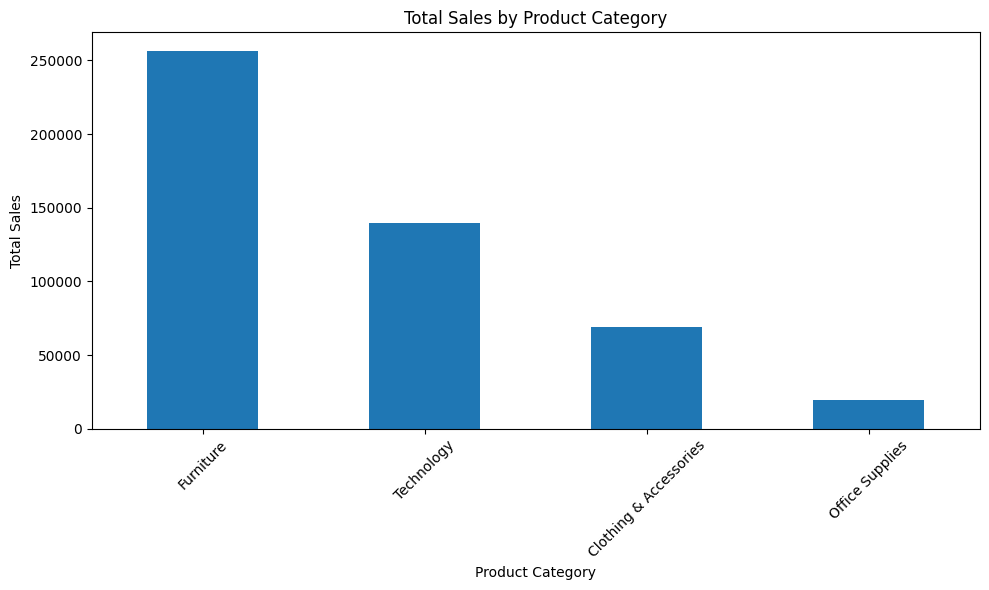

In [28]:
# Product Sales Visualization

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

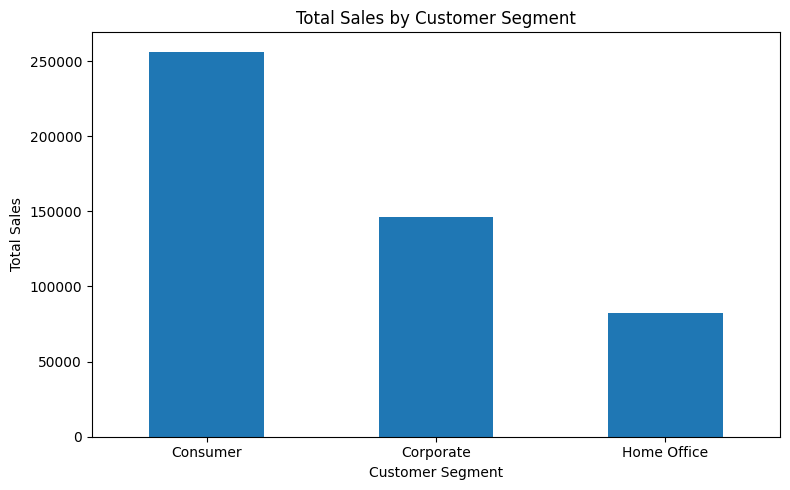

In [29]:
# Customer Segment Sales Visualization

plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

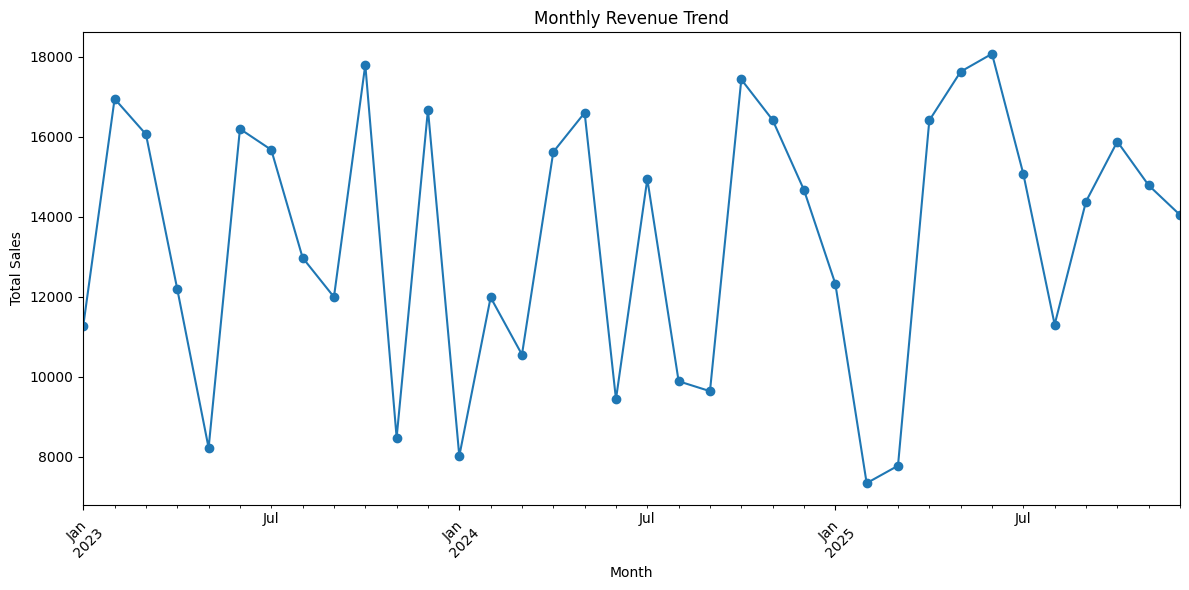

In [30]:
# Monthly Revenue Trend Visualization

plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

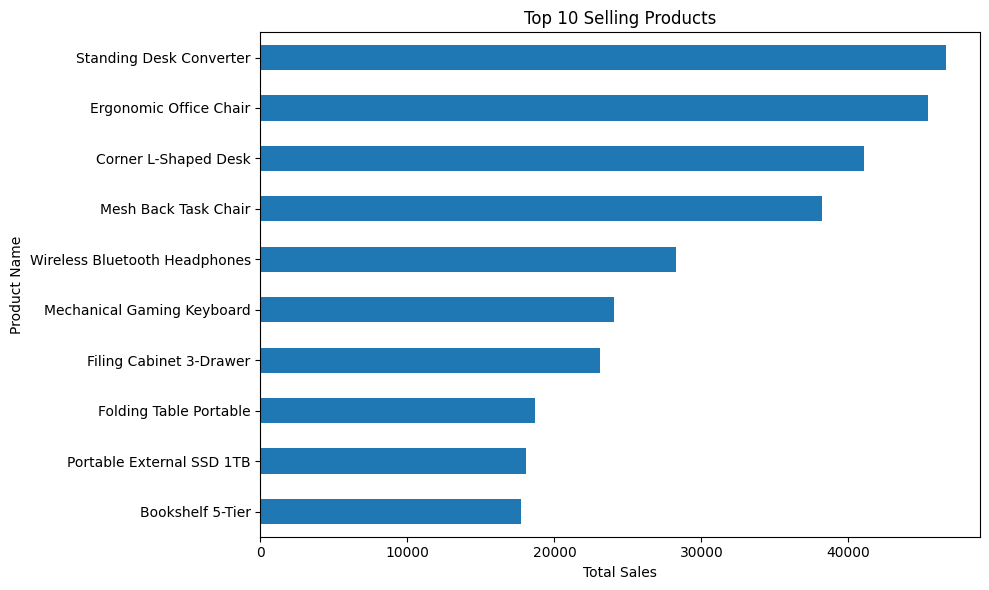

In [31]:
# Top 10 Selling Products Visualization

top_10_products = top_products.head(10)

plt.figure(figsize=(10, 6))

top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()

plt.show()

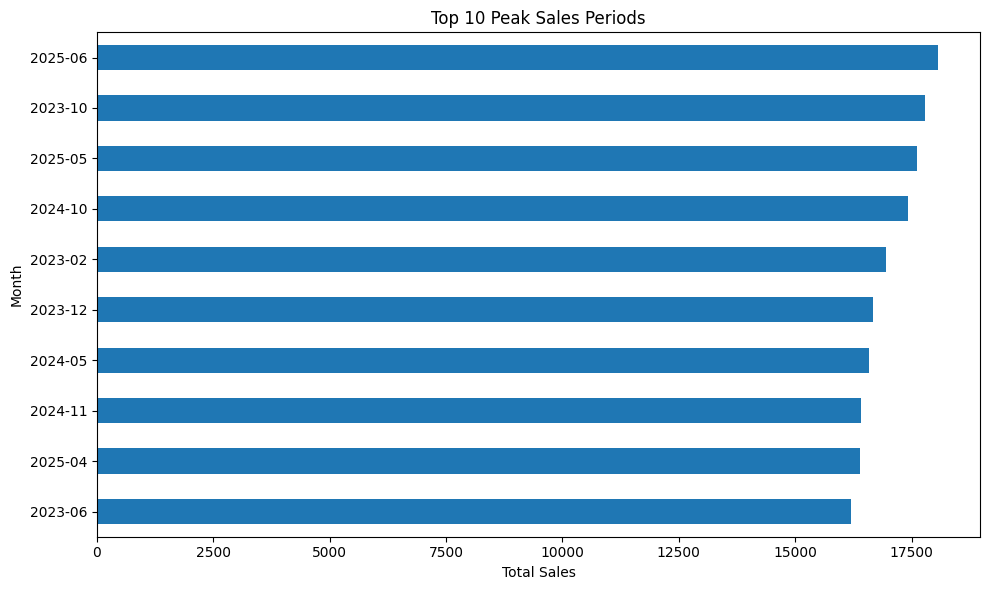

In [32]:
# Peak Sales Periods Visualization

top_peak_periods = peak_sales_periods.head(10)

plt.figure(figsize=(10, 6))

top_peak_periods.sort_values().plot(kind="barh")

plt.title("Top 10 Peak Sales Periods")
plt.xlabel("Total Sales")
plt.ylabel("Month")
plt.tight_layout()

plt.show()

In [33]:
# Business Insights

print("BUSINESS INSIGHTS")
print("-----------------")

print("1. Furniture is the highest-selling product category.")
print("2. Office Supplies is the lowest-selling product category.")
print("3. Consumer customers generate the highest total sales.")
print("4. Home Office customers generate the lowest total sales.")
print("5. Standing Desk Converter is the top-selling product.")
print("6. June 2025 recorded the highest monthly sales.")

BUSINESS INSIGHTS
-----------------
1. Furniture is the highest-selling product category.
2. Office Supplies is the lowest-selling product category.
3. Consumer customers generate the highest total sales.
4. Home Office customers generate the lowest total sales.
5. Standing Desk Converter is the top-selling product.
6. June 2025 recorded the highest monthly sales.


In [34]:
# Business Recommendations

print("BUSINESS RECOMMENDATIONS")
print("------------------------")

print("1. Focus more on high-performing Furniture products.")
print("2. Promote Office Supplies products to improve their sales.")
print("3. Target Consumer customers with suitable offers and promotions.")
print("4. Develop strategies to increase sales from Home Office customers.")
print("5. Maintain sufficient stock of top-selling products.")
print("6. Plan promotions around high-performing sales periods.")

BUSINESS RECOMMENDATIONS
------------------------
1. Focus more on high-performing Furniture products.
2. Promote Office Supplies products to improve their sales.
3. Target Consumer customers with suitable offers and promotions.
4. Develop strategies to increase sales from Home Office customers.
5. Maintain sufficient stock of top-selling products.
6. Plan promotions around high-performing sales periods.


In [35]:
# Detailed E-Commerce Sales Data Analysis Report

report = """
============================================================
        E-COMMERCE SALES DATA ANALYSIS REPORT
============================================================

1. PROJECT OVERVIEW
------------------------------------------------------------
This project focuses on analyzing an e-commerce sales dataset
using Python to understand product performance, customer
behavior, and revenue trends.

The analysis was performed using Pandas, NumPy, and Matplotlib.
The objective was to identify high-performing products and
categories, understand customer segment performance, examine
monthly revenue trends, and generate meaningful business
insights and recommendations.

2. DATASET OVERVIEW
------------------------------------------------------------
The dataset contains 2,000 records and 15 columns covering
order details, customer information, product information,
sales, shipping costs, profit, discounts, and payment methods.

Key fields include:
- Order ID
- Order Date
- Customer Name
- Customer Segment
- Country
- Region
- Product Category
- Product Name
- Quantity
- Unit Price
- Discount Percentage
- Total Sales
- Shipping Cost
- Profit
- Payment Method

3. DATA CLEANING AND PREPROCESSING
------------------------------------------------------------
The dataset was loaded and examined using Pandas.

The following data quality checks were performed:
- Missing value check
- Duplicate record check
- Date format validation
- Quantity validation
- Unit price validation
- Total sales validation
- Shipping cost validation
- Discount percentage validation

Results:
- Missing values: None
- Duplicate records: None
- Invalid quantities: None
- Invalid unit prices: None
- Invalid total sales values: None
- Negative shipping costs: None
- Invalid discount percentages: None

The Order_Date column was converted into datetime format to
support monthly revenue analysis.

Since the dataset did not contain missing, duplicate, or
invalid records based on the performed checks, no corrective
data modifications were required.

4. PRODUCT SALES ANALYSIS
------------------------------------------------------------
Product category performance was analyzed by aggregating
Total_Sales for each Product_Category.

Key finding:
Furniture generated the highest total sales among all product
categories, with total sales of 256,274.68.

Technology generated 139,518.22 in total sales, while
Clothing & Accessories generated 69,375.63.

Office Supplies recorded the lowest category-level sales,
with total sales of 19,390.81.

This indicates that Furniture was the strongest-performing
product category in the dataset.

5. CUSTOMER BEHAVIOR ANALYSIS
------------------------------------------------------------
Customer performance was analyzed based on Customer_Segment
and Total_Sales.

The Consumer segment generated the highest total sales of
256,287.74.

The Corporate segment generated 146,050.39, while the
Home Office segment generated 82,221.21.

The results show that Consumer customers contributed the
largest share of sales among the analyzed customer segments.

6. REVENUE TREND ANALYSIS
------------------------------------------------------------
Monthly Total_Sales were analyzed using the Order_Date field.

The analysis covered monthly sales from 2023 through 2025.
Sales varied across different months, indicating fluctuations
in monthly revenue performance.

The highest monthly sales were recorded in June 2025, with
total sales of 18,068.09.

Other strong sales periods included:
- October 2023: 17,794.60
- May 2025: 17,621.80
- October 2024: 17,426.05

These periods represent the strongest monthly sales
performance in the analyzed dataset.

7. TOP-SELLING PRODUCTS
------------------------------------------------------------
Individual product performance was analyzed by aggregating
Total_Sales for each Product_Name.

The top-performing products were:

1. Standing Desk Converter - 46,614.22
2. Ergonomic Office Chair - 45,405.15
3. Corner L-Shaped Desk - 41,070.48
4. Mesh Back Task Chair - 38,179.77
5. Wireless Bluetooth Headphones - 28,258.70

Standing Desk Converter was the highest-selling individual
product in the dataset.

8. KEY BUSINESS INSIGHTS
------------------------------------------------------------
Based on the analysis, the following business insights were
identified:

• Furniture is the strongest-performing product category.
• Office Supplies has the lowest category-level sales.
• Consumer customers generate the highest sales among the
  analyzed customer segments.
• Standing Desk Converter is the top-selling individual
  product.
• June 2025 recorded the highest monthly sales.
• Several strong sales periods occurred during April-June
  and October-November across different years.

9. BUSINESS RECOMMENDATIONS
------------------------------------------------------------
Based on the observed sales patterns, the following
recommendations can be considered:

1. Strengthen the Furniture product category by maintaining
   availability of high-performing products.

2. Focus on the top-selling products, particularly the
   Standing Desk Converter, Ergonomic Office Chair, and
   Corner L-Shaped Desk.

3. Develop targeted promotions for the Office Supplies
   category to improve its sales performance.

4. Continue engaging Consumer customers through relevant
   offers and product promotions because this segment
   generated the highest sales.

5. Explore strategies to improve sales from the Home Office
   segment.

6. Use historical high-performing sales periods to support
   future promotional and inventory planning.

10. VISUALIZATION
------------------------------------------------------------
The project includes Python-based visualizations for:

- Total Sales by Product Category
- Total Sales by Customer Segment
- Monthly Revenue Trend
- Top 10 Selling Products
- Top 10 Peak Sales Periods

These visualizations make it easier to compare product
performance, customer segments, and sales trends.

11. CONCLUSION
------------------------------------------------------------
The e-commerce sales analysis provides a clear view of
product, customer, and revenue performance within the dataset.

The analysis identified Furniture as the leading product
category, Consumer as the highest-performing customer
segment, Standing Desk Converter as the top-selling product,
and June 2025 as the strongest monthly sales period.

Overall, the project demonstrates how Python-based data
analysis can be used to transform raw e-commerce data into
meaningful insights that support product, customer, and
sales-related business decisions.

============================================================
                    END OF REPORT
============================================================
"""

print(report)


        E-COMMERCE SALES DATA ANALYSIS REPORT

1. PROJECT OVERVIEW
------------------------------------------------------------
This project focuses on analyzing an e-commerce sales dataset
using Python to understand product performance, customer
behavior, and revenue trends.

The analysis was performed using Pandas, NumPy, and Matplotlib.
The objective was to identify high-performing products and
categories, understand customer segment performance, examine
monthly revenue trends, and generate meaningful business
insights and recommendations.

2. DATASET OVERVIEW
------------------------------------------------------------
The dataset contains 2,000 records and 15 columns covering
order details, customer information, product information,
sales, shipping costs, profit, discounts, and payment methods.

Key fields include:
- Order ID
- Order Date
- Customer Name
- Customer Segment
- Country
- Region
- Product Category
- Product Name
- Quantity
- Unit Price
- Discount Percentage
- Total S